# **1. Data Loading**

In [1]:
#1. Data Loading
#upload the file
from google.colab import files
uploaded = files.upload()

Saving telco_churn.csv to telco_churn.csv


In [ ]:
import os
os.listdir()


['.config', 'telco_churn (1).csv', 'telco_churn.csv', 'sample_data']

# **2. Data Cleaning**

In [2]:
#2. Data Cleaning
#sample of the data
import pandas as pd

df = pd.read_csv("telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Number of columns = 21

Churn column = 21

In [ ]:
#check for missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
#Chrun distribution
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


% of customers who churned = 26.54% (2 d.p.)

% of customers who stayed = 73.46% (2 d.p.)

Approximately 26.5% of customers in the dataset have churned. This indicates a substantial retention problem, as more than one in four customers discontinue service. From a modeling perspective, the churn rate is high enough to allow meaningful pattern detection without severe class imbalance issues.

# **3. Exploratory Data Analysis**

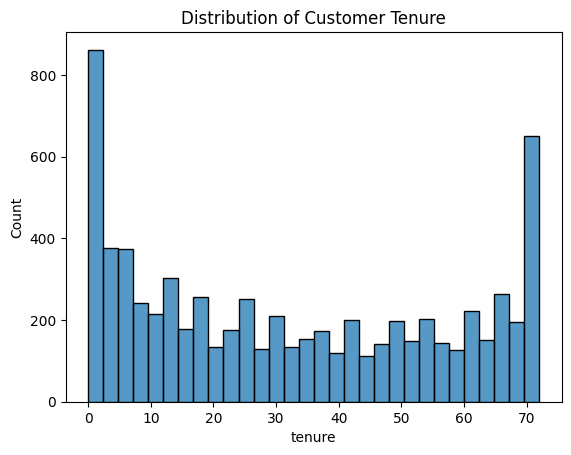

In [ ]:
#3. Exploratory Data Analysis
#visualise the distribution between Churn and other variables
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['tenure'], bins=30)
plt.title("Distribution of Customer Tenure")
plt.show()

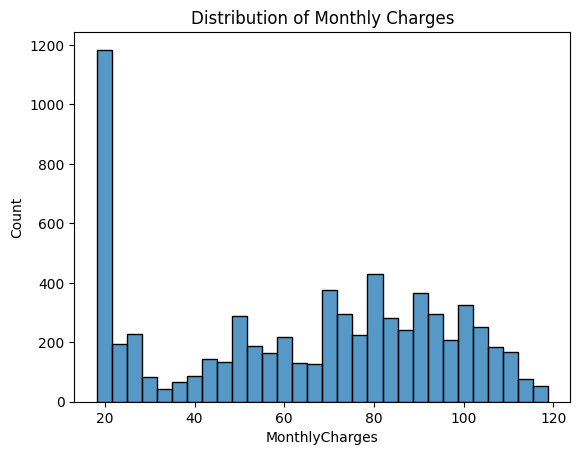

In [ ]:
sns.histplot(df['MonthlyCharges'], bins=30)
plt.title("Distribution of Monthly Charges")
plt.show()

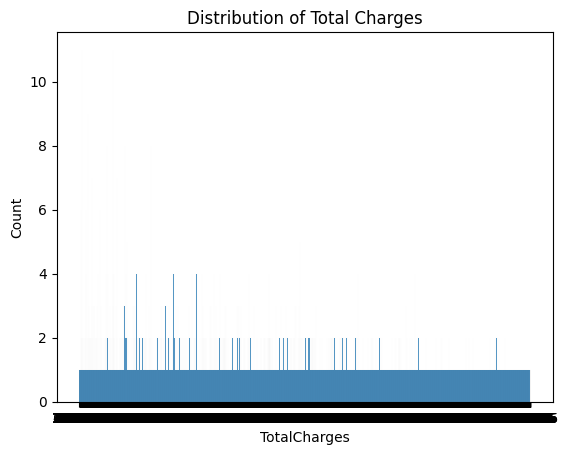

In [ ]:
sns.histplot(df['TotalCharges'], bins=30)
plt.title("Distribution of Total Charges")
plt.show()

In [ ]:
pd.crosstab(df['Contract'],df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [ ]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


Customers with month-to-month contracts show higher churn rates

Short-tenure customers are more likely to churn

Higher monthly charges may be associated with churn

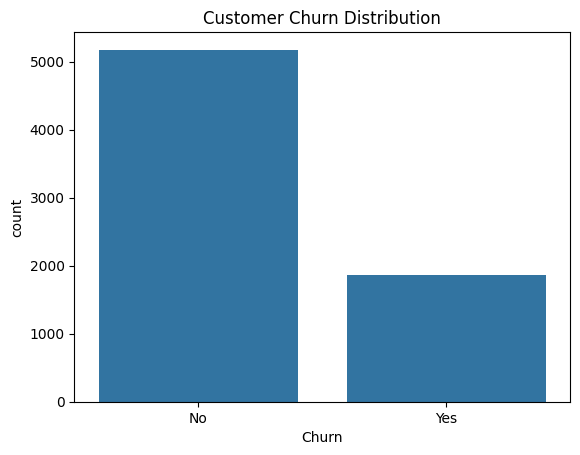

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

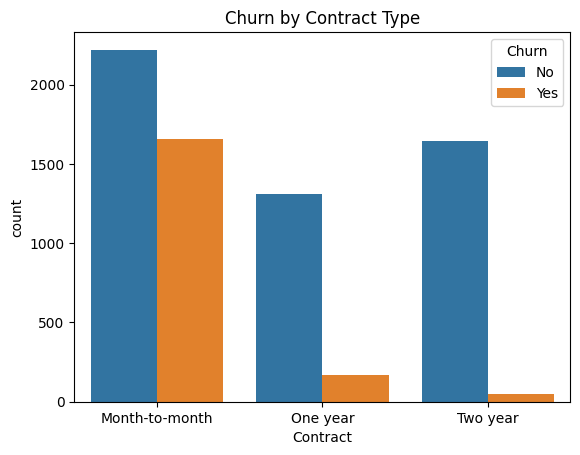

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

Month-to-month customers have the most churns

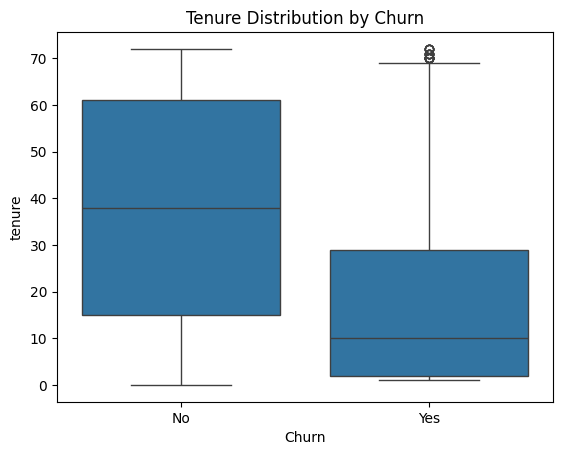

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure Distribution by Churn")
plt.show()

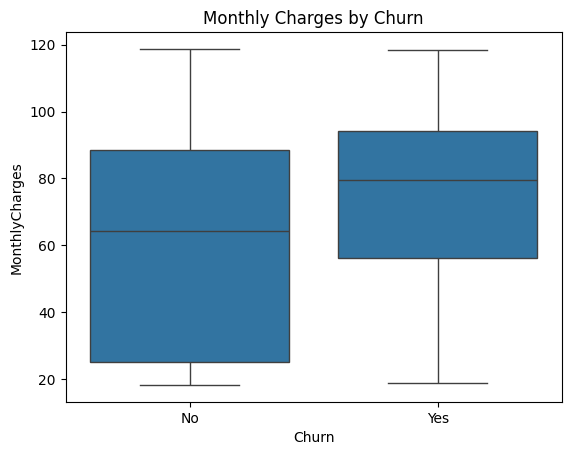

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Churn")
plt.show()

# **4. Feature Engineering / Encoding**

In [3]:
#4. Feature Engineering / Encoding
#produce heatmap (this step is skipped because the computation is too large)
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
#produce heatmap (this step is skipped because the computation is too large)
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#uderstand risk profile
df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


In [ ]:
df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)

,Churn
InternetService,
Fiber optic,0.418928
DSL,0.189591
No,0.074050


In [ ]:
df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)

,Churn
PaymentMethod,
Electronic check,0.452854
Mailed check,0.191067
Bank transfer (automatic),0.167098
Credit card (automatic),0.152431


**Contract type**: Customers on month-to-month contracts show significantly higher churn compared to those on one-year or two-year contracts. This suggests that longer commitments are associated with better retention.

**Internet Service**: Customers using fibre optic internet have a higher churn rate than those using DSL or no internet service. This may indicate pricing sensitivity, service quality concerns, or higher expectations among fibre users.

**Payment Method**:Customers who pay via electronic check churn more than those using automatic or card-based payment methods. This could suggest that customers with less automated billing are less engaged or more likely to discontinue service.

**Combined Risk Profile**
Customers on month-to-month contracts, using fibre optic internet, and paying via electronic check represent a higher-risk churn segment. These customers may benefit most from targeted retention strategies.

# **5. Model Building**

In [6]:
#5. Churn Prediction Model
#prepare features and target
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state = 42
)

In [10]:
#check column names
df_encoded.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'customerID_0003-MKNFE',
       'customerID_0004-TLHLJ', 'customerID_0011-IGKFF',
       'customerID_0013-EXCHZ', 'customerID_0013-MHZWF',
       'customerID_0013-SMEOE', 'customerID_0014-BMAQU',
       ...
       'TotalCharges_996.45', 'TotalCharges_996.85', 'TotalCharges_996.95',
       'TotalCharges_997.65', 'TotalCharges_997.75', 'TotalCharges_998.1',
       'TotalCharges_999.45', 'TotalCharges_999.8', 'TotalCharges_999.9',
       'Churn_Yes'],
      dtype='object', length=13602)

In [9]:
#confirm
print(X.shape)
print(y.shape)

(7043, 13601)
(7043,)


In [11]:
#train the model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
#make predictions
y_pred = model.predict(X_test)

# **6. Model Evaluation**

In [14]:
#6. Model Evaluation
#evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.8239886444286728
              precision    recall  f1-score   support

       False       0.86      0.91      0.88      1036
        True       0.70      0.59      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [15]:
#identify important features
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

feature_importance.head(10)

,Feature,Coefficient
7066,Contract_Two year,-1.355864
8680,TotalCharges_20.2,1.323644
8686,TotalCharges_20.5,1.154403
8563,TotalCharges_19.95,1.036475
7051,InternetService_Fiber optic,1.031888
8678,TotalCharges_20.1,1.021427
10886,TotalCharges_45.3,0.970524
8556,TotalCharges_19.6,0.963656
12797,TotalCharges_740.3,0.960356
9558,TotalCharges_288.05,0.940821


# **7. Model Insights**

In [16]:
#add predicted probabilities
y_prob = model.predict_proba(X_test)[:,1]

results = X_test.copy()
results['Actual_Churn'] = y_test.values
results['Churn_Probability'] = y_prob

In [17]:
#find high-risk group
high_risk = results[results['Churn_Probability']>0.6]
high_risk.head()

,SeniorCitizen,tenure,MonthlyCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Actual_Churn,Churn_Probability
185,0,1,24.80,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,0.735520
1807,0,1,76.35,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,0.755459
6179,1,11,95.15,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,0.770378
4640,0,1,70.00,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,0.714187
3328,0,1,70.25,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.740340


In [18]:
#profile of high-risk customers
high_risk_profiles = df.loc[high_risk.index]
high_risk_profiles.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,218,218,218.000000,218,218,218.000000,218,218,218,218,...,218,218,218,218,218,218,218,218.000000,218,218
unique,218,2,NaN,2,2,NaN,2,3,2,2,...,2,2,2,2,1,2,4,NaN,209,2
top,1024-GUALD,Female,NaN,No,No,NaN,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,NaN,74.5,Yes
freq,1,117,NaN,154,189,NaN,208,118,205,212,...,166,209,110,115,218,192,179,NaN,2,164
mean,NaN,NaN,0.344037,NaN,NaN,8.490826,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.796330,NaN,NaN
std,NaN,NaN,0.476146,NaN,NaN,9.109291,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.495381,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.800000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.700000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.825000,NaN,NaN
75%,NaN,NaN,1.000000,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN


Essentially, customers who are new (mean tenure = 8.5 months); on month-to-month contracts; and paying higher monthly charges (avg = 82.8 up to 109) are the most likely to churn.

You also see patterns like:
*   Fiber optic internet appears frequently
*   Certain add-on services (like tech support or security) vary

This suggests that certain product bundles may be linked to dissatisfaction or unmet expectations.